In [1]:
import os
import sys
from pathlib import Path

if os.getcwd().endswith("scripts"):
    os.chdir("..")
sys.path.insert(0, "src")

import yaml
import torch

from utils import resolve_device, set_seed, plot_history
from data import get_loaders
from models import PlainCNN, ResNet
from trainer import train, evaluate



In [2]:
config_path = "configs.yaml"
with open(config_path, "r") as f:   
    cfg = yaml.safe_load(f)

device = resolve_device(cfg["device"])
print(f"Device: {device}")

SEED = cfg.get("seed", 42)
set_seed(SEED)
print(f"Random seed set to: {SEED}")


Device: xpu
Random seed set to: 42


In [3]:
train_loader, val_loader, test_loader = get_loaders(
    data_dir="data",
    batch_size=cfg["data"]["batch_size"],
    num_workers=cfg["data"]["num_workers"],
    augment=cfg["train"]["augment"],
    val_split_seed=cfg["train"]["val_split_seed"]
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of testing batches: {len(test_loader)}")


Number of training batches: 704
Number of validation batches: 79
Number of testing batches: 157


In [4]:
plain_cnn = PlainCNN(num_classes=cfg["model"]["num_classes"]).to(device)
plain_cnn_optimizer = torch.optim.Adam(plain_cnn.parameters(), lr=1e-3)

resnet = ResNet(num_classes=cfg["model"]["num_classes"]).to(device)
resnet_optimizer = torch.optim.Adam(resnet.parameters(), lr=1e-3)

criterion = torch.nn.CrossEntropyLoss()

# print(plain_cnn)
print(f"Number of parameters (Plain CNN): {sum(p.numel() for p in plain_cnn.parameters()):,}")
# print(resnet)
print(f"Number of parameters (ResNet): {sum(p.numel() for p in resnet.parameters()):,}")

Number of parameters (Plain CNN): 289,194
Number of parameters (ResNet): 299,530


[23:21:03] Epoch 01/30
Train: [1.2190, 0.5606] | Val: [1.0543, 0.6154] | 17.61s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.6154

[23:21:21] Epoch 02/30
Train: [0.8313, 0.7065] | Val: [0.8441, 0.6970] | 15.70s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.6970

[23:21:36] Epoch 03/30
Train: [0.6716, 0.7661] | Val: [0.7385, 0.7448] | 15.64s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.7448

[23:21:52] Epoch 04/30
Train: [0.5619, 0.8054] | Val: [0.7423, 0.7340] | 15.77s

[23:22:08] Epoch 05/30
Train: [0.4924, 0.8305] | Val: [0.5940, 0.7910] | 15.63s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.7910

[23:22:23] Epoch 06/30
Train: [0.4352, 0.8481] | Val: [0.5540, 0.8054] | 15.78s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.8054

[23:22:39] Epoch 07/30
Train: [0.3884, 0.8661] | Val: [0.7348, 0.7578] | 15.76s

[23:22:55] Epoch 08/30
Train: [0.3422, 0.8813] | Val: [0.6

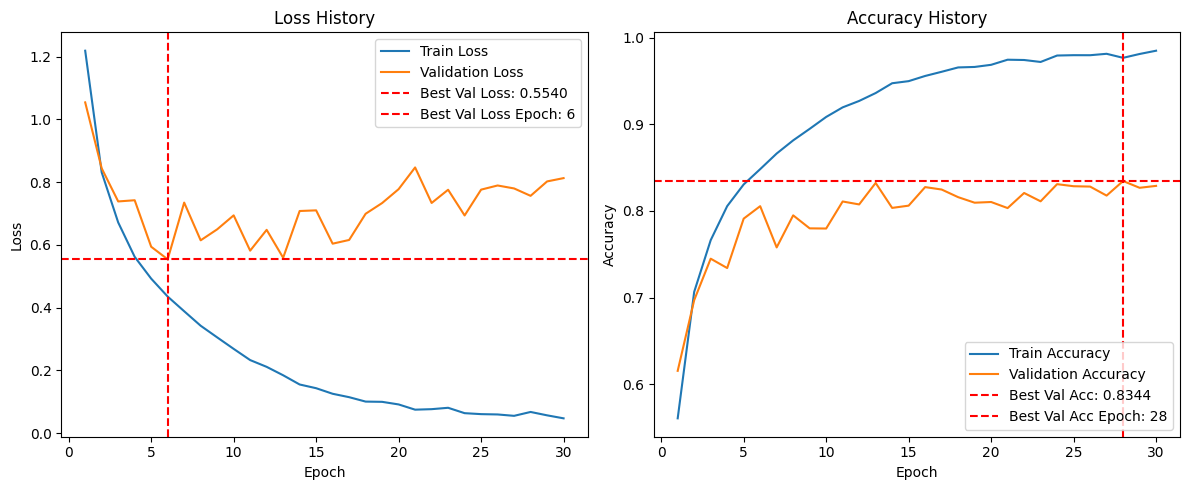

In [5]:
epochs = cfg.get("train", {}).get("epochs", 10)
ckpt_dir = cfg.get("train", {}).get("checkpoint_dir", "checkpoints")
ckpt_dir = Path(ckpt_dir)

history = train(
    model=plain_cnn,
    optimizer=plain_cnn_optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epochs,
    ckpt_dir=ckpt_dir,
    save_name="best_plain_cnn.pt"
)

plot_history(history, save_path=ckpt_dir / "history_plain_cnn.png", show=True)


In [6]:
print(f"Loading best model from {ckpt_dir / 'best_plain_cnn.pt'}")
print(f"Best Val Loss: {min(history['val_loss']):.4f} | Best Val Acc: {max(history['val_acc']):.4f}")
plain_cnn.load_state_dict(torch.load(ckpt_dir / "best_plain_cnn.pt"))

test_loss, test_acc = evaluate(plain_cnn, criterion, test_loader, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


Loading best model from checkpoints\best_plain_cnn.pt
Best Val Loss: 0.5540 | Best Val Acc: 0.8344
Test Loss: 0.7861 | Test Acc: 0.8260


[23:29:01] Epoch 01/30
Train: [1.3240, 0.5148] | Val: [1.1073, 0.5954] | 13.16s
New best model saved at checkpoints\best_resnet.pt with val_acc: 0.5954

[23:29:14] Epoch 02/30
Train: [0.9631, 0.6559] | Val: [0.9637, 0.6536] | 11.59s
New best model saved at checkpoints\best_resnet.pt with val_acc: 0.6536

[23:29:26] Epoch 03/30
Train: [0.7992, 0.7180] | Val: [0.7771, 0.7214] | 11.53s
New best model saved at checkpoints\best_resnet.pt with val_acc: 0.7214

[23:29:37] Epoch 04/30
Train: [0.6819, 0.7607] | Val: [0.7716, 0.7262] | 11.51s
New best model saved at checkpoints\best_resnet.pt with val_acc: 0.7262

[23:29:49] Epoch 05/30
Train: [0.5906, 0.7943] | Val: [0.7516, 0.7362] | 11.67s
New best model saved at checkpoints\best_resnet.pt with val_acc: 0.7362

[23:30:01] Epoch 06/30
Train: [0.5208, 0.8187] | Val: [0.6543, 0.7668] | 11.54s
New best model saved at checkpoints\best_resnet.pt with val_acc: 0.7668

[23:30:12] Epoch 07/30
Train: [0.4585, 0.8384] | Val: [0.6854, 0.7610] | 11.91s

[

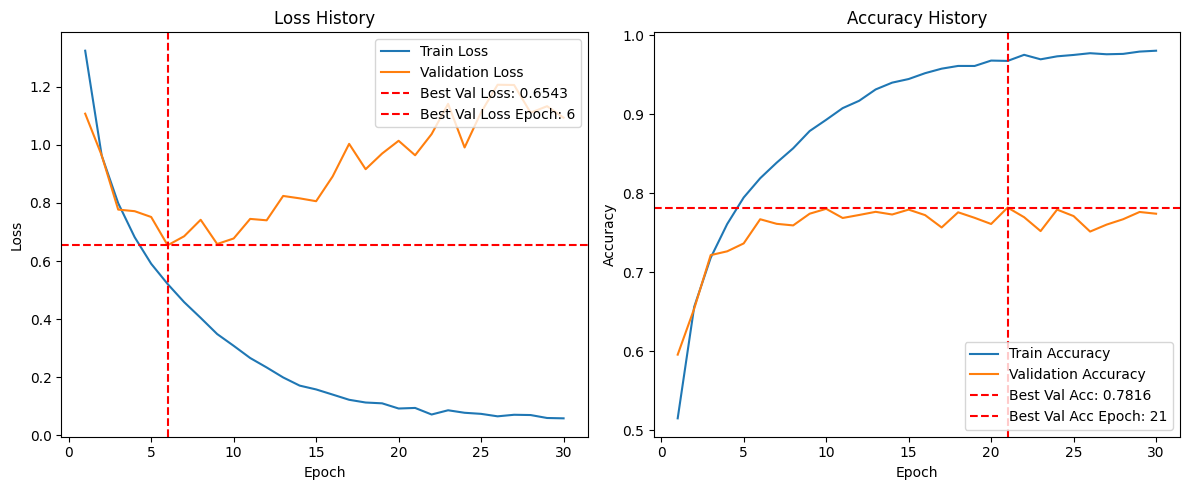

In [7]:
epochs = cfg.get("train", {}).get("epochs", 10)
ckpt_dir = cfg.get("train", {}).get("checkpoint_dir", "checkpoints")
ckpt_dir = Path(ckpt_dir)

history = train(
    model=resnet,
    optimizer=resnet_optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epochs,
    ckpt_dir=ckpt_dir,
    save_name="best_resnet.pt"
)

plot_history(history, save_path=ckpt_dir / "history_resnet.png", show=True)


In [8]:
print(f"Loading best model from {ckpt_dir / 'best_resnet.pt'}")
print(f"Best Val Loss: {min(history['val_loss']):.4f} | Best Val Acc: {max(history['val_acc']):.4f}")
resnet.load_state_dict(torch.load(ckpt_dir / "best_resnet.pt"))

test_loss, test_acc = evaluate(resnet, criterion, test_loader, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


Loading best model from checkpoints\best_resnet.pt
Best Val Loss: 0.6543 | Best Val Acc: 0.7816
Test Loss: 1.0426 | Test Acc: 0.7789
